# Análise exploratória

“Sem diagnóstico” significa apenas que a pessoa respondeu que não recebeu diagnóstico profissional na variável `Q092`.

### 1. Identificação e desenho da pesquisa

- `V0001`: Unidade da Federação;
- `V0024`: estrato amostral, quando disponível;
- `UPA_PNS`: unidade primária de amostragem, quando disponível;
- `V00291`: peso amostral do morador selecionado;
- `V0025` em 2013 e `V0025A` em 2019: identificação do morador selecionado.

### 2. Características demográficas e territoriais

- `C006`: sexo;
- `C008`: idade;
- `C009`: raça ou cor;
- `V0026`: situação urbana ou rural;
- `V0001`: UF e grande região.

### 3. Condições socioeconômicas

- `VDD004A`: escolaridade;
- `VDF003`: rendimento domiciliar per capita;
- `VDE001` e `VDE002`: condição na força de trabalho, quando disponíveis.

### 4. Saúde mental e depressão

- `Q092`: diagnóstico profissional de depressão;
- `N010` a `N018`: nove sintomas utilizados no PHQ-9;
- escore total do PHQ-9;
- PHQ-9 igual ou superior a 10;
- gravidade dos sintomas;
- pensamentos de morte ou autoagressão;
- PHQ-9 elevado sem diagnóstico relatado.

### 5. Tratamento, acesso e consequências

- `Q094`: acompanhamento regular;
- `Q098`: obtenção de medicamento em serviço público;
- `Q100`: pagamento por medicamentos;
- `Q104`: pagamento pelo atendimento;
- `Q105`: atendimento pelo SUS;
- `Q106`: encaminhamento para saúde mental;
- `Q109`: grau de limitação relacionado à depressão;


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

## 2. Informar os arquivos

O notebook **não baixa nenhum dado** e **não abre arquivos ZIP**.

Coloque na mesma pasta:

- `PNS_2013.csv`
- `PNS_2019.csv`

In [ ]:
PASTA = Path.cwd()

arquivo_2013 = PASTA / "PNS_2013.csv"
arquivo_2019 = PASTA / "pns2019.csv"


## 3. Definir as variáveis de interesse

Primeiro informamos todas as variáveis que podem ser úteis. Depois o notebook verifica quais delas realmente existem em cada CSV.

As variáveis essenciais são obrigatórias. As variáveis de ocupação, tratamento e desenho amostral são opcionais.

In [ ]:
itens_phq9 = [
    "N010", "N011", "N012",
    "N013", "N014", "N015",
    "N016", "N017", "N018",
]

colunas_essenciais_2013 = [
    "V0025",
    "V0001", "V0026",
    "C006", "C008", "C009",
    "V00291", "VDD004A", "VDF003",
    "Q092",
    *itens_phq9,
]

colunas_essenciais_2019 = [
    "V0025A",
    "V0001", "V0026",
    "C006", "C008", "C009",
    "V00291", "VDD004A", "VDF003",
    "Q092",
    *itens_phq9,
]

colunas_opcionais_comuns = [
    "V0024", "UPA_PNS", "V0031",
    "VDE001", "VDE002",
    "Q094", "Q098", "Q100",
    "Q104", "Q105", "Q106", "Q109",
]

colunas_opcionais_2013 = [
    "Q093", "Q101", "Q102", "Q107",
]

colunas_opcionais_2019 = [
    "Q09301", "Q10101", "Q10202", "Q10701", "Q09502",
]

In [ ]:
cabecalho_2013 = pd.read_csv(
    arquivo_2013,
    sep=";",
    nrows=0,
)

cabecalho_2019 = pd.read_csv(
    arquivo_2019,
    sep=",",
    nrows=0,
)

cabecalho_2013.columns = cabecalho_2013.columns.str.strip()
cabecalho_2019.columns = cabecalho_2019.columns.str.strip()

colunas_2013 = [
    coluna
    for coluna in (
        colunas_essenciais_2013
        + colunas_opcionais_comuns
        + colunas_opcionais_2013
    )
    if coluna in cabecalho_2013.columns
]

colunas_2019 = [
    coluna
    for coluna in (
        colunas_essenciais_2019
        + colunas_opcionais_comuns
        + colunas_opcionais_2019
    )
    if coluna in cabecalho_2019.columns
]

print("Colunas que serão lidas em 2013:", len(colunas_2013))
print("Colunas que serão lidas em 2019:", len(colunas_2019))

## Inventário das variáveis



In [ ]:
descricao_variaveis = {
    "V0001": ("Território", "Unidade da Federação"),
    "V0024": ("Desenho amostral", "Estrato amostral"),
    "UPA_PNS": ("Desenho amostral", "Unidade primária de amostragem"),
    "V0026": ("Território", "Situação urbana ou rural"),
    "C006": ("Demográfico", "Sexo"),
    "C008": ("Demográfico", "Idade"),
    "C009": ("Demográfico", "Raça ou cor"),
    "V00291": ("Desenho amostral", "Peso amostral"),
    "VDD004A": ("Socioeconômico", "Escolaridade"),
    "VDF003": ("Socioeconômico", "Renda domiciliar per capita"),
    "VDE001": ("Socioeconômico", "Participação na força de trabalho"),
    "VDE002": ("Socioeconômico", "Situação de ocupação"),
    "Q092": ("Saúde mental", "Diagnóstico profissional de depressão"),
    "Q094": ("Tratamento e acesso", "Acompanhamento regular"),
    "Q098": ("Tratamento e acesso", "Medicamento obtido no serviço público"),
    "Q100": ("Tratamento e acesso", "Pagamento por medicamentos"),
    "Q104": ("Tratamento e acesso", "Pagamento pelo atendimento"),
    "Q105": ("Tratamento e acesso", "Atendimento pelo SUS"),
    "Q106": ("Tratamento e acesso", "Encaminhamento para saúde mental"),
    "Q109": ("Saúde e consequências", "Grau de limitação relacionado à depressão"),
    "Q093": ("História do diagnóstico", "Idade ao diagnóstico em 2013"),
    "Q09301": ("História do diagnóstico", "Idade ao diagnóstico em 2019"),
    "Q101": ("Tratamento e acesso", "Assistência no último ano em 2013"),
    "Q10101": ("Tratamento e acesso", "Assistência no último ano em 2019"),
    "Q102": ("Tratamento e acesso", "Local de atendimento em 2013"),
    "Q10202": ("Tratamento e acesso", "Local de atendimento em 2019"),
    "Q107": ("Tratamento e acesso", "Consultas necessárias com especialista em 2013"),
    "Q10701": ("Tratamento e acesso", "Consultas necessárias com especialista em 2019"),
}

for coluna in itens_phq9:
    descricao_variaveis[coluna] = (
        "Sintomas do PHQ-9",
        f"Item do PHQ-9: {coluna}",
    )

todas = sorted(
    set(colunas_2013 + colunas_2019)
    - {"V0025", "V0025A"}
)

inventario = pd.DataFrame({
    "Variável": todas,
    "Grupo": [
        descricao_variaveis.get(coluna, ("Outras", ""))[0]
        for coluna in todas
    ],
    "Descrição": [
        descricao_variaveis.get(coluna, ("", "Variável disponível"))[1]
        for coluna in todas
    ],
    "Disponível em 2013": [
        coluna in colunas_2013
        for coluna in todas
    ],
    "Disponível em 2019": [
        coluna in colunas_2019
        for coluna in todas
    ],
})

display(inventario)

In [ ]:
pns_2013 = pd.read_csv(
    arquivo_2013,
    sep=";",
    decimal=",",
    usecols=colunas_2013,
    na_values=[" ", "NA", ""],
    low_memory=False,
)

pns_2019 = pd.read_csv(
    arquivo_2019,
    sep=",",
    decimal=".",
    usecols=colunas_2019,
    na_values=[" ", "NA", ""],
    low_memory=False,
)

print("Formato da PNS 2013:", pns_2013.shape)
print("Formato da PNS 2019:", pns_2019.shape)

Converter as colunas para números

In [ ]:
for coluna in pns_2013.columns:
    pns_2013[coluna] = pd.to_numeric(
        pns_2013[coluna],
        errors="coerce",
    )

for coluna in pns_2019.columns:
    pns_2019[coluna] = pd.to_numeric(
        pns_2019[coluna],
        errors="coerce",
    )

In [ ]:
pns_2013 = pns_2013[
    (pns_2013["V0025"] == 1)
    & (pns_2013["C008"] >= 18)
].copy()

pns_2019 = pns_2019[
    (pns_2019["V0025A"] == 1)
    & (pns_2019["C008"] >= 18)
].copy()

pns_2013["Ano"] = 2013
pns_2019["Ano"] = 2019

pns_2013 = pns_2013.drop(columns="V0025")
pns_2019 = pns_2019.drop(columns="V0025A")

dados = pd.concat(
    [pns_2013, pns_2019],
    ignore_index=True,
)

print("Adultos selecionados em 2013:", len(pns_2013))
print("Adultos selecionados em 2019:", len(pns_2019))
print("Total:", len(dados))

display(dados.head())

## Variáveis demográficas e territoriais

In [ ]:
dados["Peso"] = dados["V00291"].where(
    dados["V00291"] > 0
)

dados["Sexo"] = dados["C006"].map({
    1: "Homem",
    2: "Mulher",
})

dados["Raça/cor"] = dados["C009"].map({
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena",
})

dados["Área"] = dados["V0026"].map({
    1: "Urbana",
    2: "Rural",
})

dados["Faixa etária"] = pd.cut(
    dados["C008"],
    bins=[17, 29, 39, 49, 59, 69, np.inf],
    labels=[
        "18–29",
        "30–39",
        "40–49",
        "50–59",
        "60–69",
        "70+",
    ],
)

nomes_uf = {
    11: "Rondônia",
    12: "Acre",
    13: "Amazonas",
    14: "Roraima",
    15: "Pará",
    16: "Amapá",
    17: "Tocantins",
    21: "Maranhão",
    22: "Piauí",
    23: "Ceará",
    24: "Rio Grande do Norte",
    25: "Paraíba",
    26: "Pernambuco",
    27: "Alagoas",
    28: "Sergipe",
    29: "Bahia",
    31: "Minas Gerais",
    32: "Espírito Santo",
    33: "Rio de Janeiro",
    35: "São Paulo",
    41: "Paraná",
    42: "Santa Catarina",
    43: "Rio Grande do Sul",
    50: "Mato Grosso do Sul",
    51: "Mato Grosso",
    52: "Goiás",
    53: "Distrito Federal",
}

dados["UF"] = dados["V0001"].map(nomes_uf)

dados["Região"] = pd.Series(
    pd.NA,
    index=dados.index,
    dtype="object",
)

dados.loc[dados["V0001"].between(11, 17), "Região"] = "Norte"
dados.loc[dados["V0001"].between(21, 29), "Região"] = "Nordeste"
dados.loc[dados["V0001"].between(31, 35), "Região"] = "Sudeste"
dados.loc[dados["V0001"].between(41, 43), "Região"] = "Sul"
dados.loc[dados["V0001"].between(50, 53), "Região"] = "Centro-Oeste"

display(
    dados[
        [
            "Ano", "C008", "Faixa etária",
            "Sexo", "Raça/cor",
            "UF", "Região", "Área",
        ]
    ].head(10)
)

## Variáveis socioeconômicas

In [ ]:
dados["Escolaridade"] = dados["VDD004A"].map({
    1: "Sem instrução / Fundamental incompleto",
    2: "Sem instrução / Fundamental incompleto",
    3: "Fundamental completo / Médio incompleto",
    4: "Fundamental completo / Médio incompleto",
    5: "Médio completo",
    6: "Superior",
    7: "Superior",
})

dados["Renda per capita"] = dados["VDF003"].where(
    dados["VDF003"] >= 0
)

dados["Quintil de renda"] = pd.Series(
    pd.NA,
    index=dados.index,
    dtype="object",
)

rotulos_renda = [
    "Q1 — menor renda",
    "Q2",
    "Q3",
    "Q4",
    "Q5 — maior renda",
]

for ano in [2013, 2019]:
    filtro = (
        (dados["Ano"] == ano)
        & dados["Renda per capita"].notna()
    )

    renda = dados.loc[filtro, "Renda per capita"]
    postos = renda.rank(method="first")

    dados.loc[filtro, "Quintil de renda"] = pd.qcut(
        postos,
        q=5,
        labels=rotulos_renda,
    ).astype(str)

if {"VDE001", "VDE002"}.issubset(dados.columns):
    dados["Situação de ocupação"] = pd.Series(
        pd.NA,
        index=dados.index,
        dtype="object",
    )

    dados.loc[
        dados["VDE002"] == 1,
        "Situação de ocupação",
    ] = "Ocupada"

    dados.loc[
        dados["VDE002"] == 2,
        "Situação de ocupação",
    ] = "Desocupada"

    dados.loc[
        dados["VDE001"] == 2,
        "Situação de ocupação",
    ] = "Fora da força de trabalho"

display(
    dados[
        [
            "Ano",
            "Escolaridade",
            "Renda per capita",
            "Quintil de renda",
        ]
    ].head(10)
)

## Indicadores de depressão
A variável `Q092` será transformada em:

- 1: relatou diagnóstico profissional;
- 0: não relatou diagnóstico;
- ausente: resposta inválida.

### PHQ-9

Cada item de `N010` a `N018` recebe de 0 a 3 pontos. O total varia de 0 a 27.

In [ ]:
dados["Diagnóstico"] = dados["Q092"].map({
    1: 1,
    2: 0,
})

dados["Diagnóstico — texto"] = dados["Q092"].map({
    1: "Com diagnóstico",
    2: "Sem diagnóstico",
})

respostas_phq9 = dados[itens_phq9].copy()

for coluna in itens_phq9:
    respostas_phq9[coluna] = respostas_phq9[coluna].where(
        respostas_phq9[coluna].between(1, 4)
    )

dados["PHQ-9"] = (
    respostas_phq9 - 1
).sum(axis=1)

dados.loc[
    respostas_phq9.isna().any(axis=1),
    "PHQ-9",
] = np.nan

dados["PHQ-9 ≥ 10"] = np.where(
    dados["PHQ-9"].notna(),
    (dados["PHQ-9"] >= 10).astype(int),
    np.nan,
)

dados["Gravidade PHQ-9"] = pd.cut(
    dados["PHQ-9"],
    bins=[-0.1, 4, 9, 14, 19, 27],
    labels=[
        "Mínima (0–4)",
        "Leve (5–9)",
        "Moderada (10–14)",
        "Moderadamente grave (15–19)",
        "Grave (20–27)",
    ],
)

dados["Pensamentos de morte/autoagressão"] = np.where(
    dados["N018"].between(1, 4),
    (dados["N018"] > 1).astype(int),
    np.nan,
)

dados["PHQ-9 elevado sem diagnóstico"] = np.where(
    dados["PHQ-9 ≥ 10"].notna()
    & dados["Diagnóstico"].notna(),
    (
        (dados["PHQ-9 ≥ 10"] == 1)
        & (dados["Diagnóstico"] == 0)
    ).astype(int),
    np.nan,
)

display(
    dados[
        [
            "Ano",
            "Diagnóstico — texto",
            "PHQ-9",
            "PHQ-9 ≥ 10",
            "Gravidade PHQ-9",
            "Pensamentos de morte/autoagressão",
            "PHQ-9 elevado sem diagnóstico",
        ]
    ].head(10)
)

## Criar variáveis opcionais de tratamento e acesso

Esta célula só cria um indicador quando a variável original está disponível.

In [ ]:
variaveis_tratamento_criadas = []

if "Q094" in dados.columns:
    dados["Acompanhamento regular"] = np.where(
        dados["Q094"].isin([1, 2, 3]),
        (dados["Q094"] == 1).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append("Acompanhamento regular")

if "Q098" in dados.columns:
    dados["Medicamento no serviço público"] = np.where(
        dados["Q098"].isin([1, 2, 3]),
        dados["Q098"].isin([1, 2]).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append(
        "Medicamento no serviço público"
    )

if "Q100" in dados.columns:
    dados["Pagou por medicamentos"] = np.where(
        dados["Q100"].isin([1, 2]),
        (dados["Q100"] == 1).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append("Pagou por medicamentos")

if "Q104" in dados.columns:
    dados["Pagou pelo atendimento"] = np.where(
        dados["Q104"].isin([1, 2]),
        (dados["Q104"] == 1).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append("Pagou pelo atendimento")

if "Q105" in dados.columns:
    dados["Atendimento pelo SUS"] = np.where(
        dados["Q105"].isin([1, 2, 3]),
        (dados["Q105"] == 1).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append("Atendimento pelo SUS")

if "Q106" in dados.columns:
    dados["Encaminhamento para saúde mental"] = np.where(
        dados["Q106"].isin([1, 2, 3]),
        (dados["Q106"] == 1).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append(
        "Encaminhamento para saúde mental"
    )

if "Q109" in dados.columns:
    dados["Limitação moderada ou maior"] = np.where(
        dados["Q109"].between(1, 5),
        (dados["Q109"] >= 3).astype(int),
        np.nan,
    )
    variaveis_tratamento_criadas.append(
        "Limitação moderada ou maior"
    )

dados["Idade ao diagnóstico"] = np.nan

if "Q093" in dados.columns:
    filtro = (
        (dados["Ano"] == 2013)
        & dados["Q093"].between(0, 98)
    )
    dados.loc[filtro, "Idade ao diagnóstico"] = dados.loc[
        filtro, "Q093"
    ]

if "Q09301" in dados.columns:
    filtro = (
        (dados["Ano"] == 2019)
        & dados["Q09301"].between(0, 98)
    )
    dados.loc[filtro, "Idade ao diagnóstico"] = dados.loc[
        filtro, "Q09301"
    ]

if {"Q101", "Q10101"}.intersection(dados.columns):
    dados["Recebeu assistência no último ano"] = np.nan

    if "Q101" in dados.columns:
        filtro = (
            (dados["Ano"] == 2013)
            & dados["Q101"].between(1, 6)
        )
        dados.loc[
            filtro,
            "Recebeu assistência no último ano",
        ] = dados.loc[filtro, "Q101"].isin([1, 2]).astype(int)

    if "Q10101" in dados.columns:
        filtro = (
            (dados["Ano"] == 2019)
            & dados["Q10101"].between(1, 6)
        )
        dados.loc[
            filtro,
            "Recebeu assistência no último ano",
        ] = dados.loc[filtro, "Q10101"].isin([1, 2]).astype(int)

    variaveis_tratamento_criadas.append(
        "Recebeu assistência no último ano"
    )


In [ ]:
fluxo = (
    dados.groupby("Ano")
    .agg(
        Adultos=("Ano", "size"),
        Peso_válido=("Peso", "count"),
        Diagnóstico_válido=("Diagnóstico", "count"),
        PHQ9_completo=("PHQ-9", "count"),
        Renda_válida=("Renda per capita", "count"),
    )
    .reset_index()
)

display(fluxo)

## Dados ausentes

In [ ]:
variaveis_qualidade = [
    "Sexo",
    "C008",
    "Raça/cor",
    "Região",
    "Área",
    "Escolaridade",
    "Renda per capita",
    "Diagnóstico",
    "PHQ-9",
]

if "Situação de ocupação" in dados.columns:
    variaveis_qualidade.append("Situação de ocupação")

variaveis_qualidade += variaveis_tratamento_criadas

linhas_ausentes = []

for ano, parte in dados.groupby("Ano"):
    for coluna in variaveis_qualidade:
        linhas_ausentes.append({
            "Ano": ano,
            "Variável": coluna,
            "Quantidade ausente": int(
                parte[coluna].isna().sum()
            ),
            "Percentual ausente (%)": (
                parte[coluna].isna().mean() * 100
            ),
        })

ausentes = pd.DataFrame(linhas_ausentes)
display(ausentes)

In [ ]:
def percentual_ponderado(base, indicador):
    validos = base[
        base[indicador].notna()
        & base["Peso"].notna()
        & (base["Peso"] > 0)
    ]

    if len(validos) == 0:
        return np.nan

    return np.average(
        validos[indicador].astype(float),
        weights=validos["Peso"],
    ) * 100


def tabela_por_grupo(grupo, indicador):
    resultados = []

    base_valida = dados.dropna(subset=[grupo])

    for (ano, categoria), parte in base_valida.groupby(
        ["Ano", grupo],
        observed=True,
    ):
        validos = parte[indicador].notna()

        resultados.append({
            "Ano": ano,
            grupo: categoria,
            "Participantes válidos": int(validos.sum()),
            "Quantidade com resultado": int(
                parte.loc[validos, indicador].sum()
            ),
            "Percentual simples (%)": (
                parte.loc[validos, indicador].mean() * 100
            ),
            "Percentual ponderado (%)": percentual_ponderado(
                parte,
                indicador,
            ),
        })

    return pd.DataFrame(resultados)


def distribuicao_ponderada(grupo):
    resultados = []

    for ano, parte_ano in dados.groupby("Ano"):
        parte_valida = parte_ano.dropna(
            subset=[grupo, "Peso"]
        )

        parte_valida = parte_valida[
            parte_valida["Peso"] > 0
        ]

        total_peso = parte_valida["Peso"].sum()

        for categoria, parte in parte_valida.groupby(
            grupo,
            observed=True,
        ):
            resultados.append({
                "Ano": ano,
                grupo: categoria,
                "Participantes": len(parte),
                "Percentual ponderado (%)": (
                    parte["Peso"].sum()
                    / total_peso
                    * 100
                ),
            })

    return pd.DataFrame(resultados)


def grafico_grupo(tabela, grupo, titulo):
    tabela.pivot(
        index=grupo,
        columns="Ano",
        values="Percentual ponderado (%)",
    ).plot(
        kind="bar",
        figsize=(10, 5),
    )

    plt.title(titulo)
    plt.xlabel(grupo)
    plt.ylabel("Percentual ponderado (%)")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Ano")
    plt.tight_layout()
    plt.show()

# Distribuição demográfica, territorial e socioeconômica

In [ ]:
perfil_sexo = distribuicao_ponderada("Sexo")
perfil_idade = distribuicao_ponderada("Faixa etária")
perfil_raca = distribuicao_ponderada("Raça/cor")
perfil_regiao = distribuicao_ponderada("Região")
perfil_area = distribuicao_ponderada("Área")
perfil_escolaridade = distribuicao_ponderada("Escolaridade")
perfil_renda = distribuicao_ponderada("Quintil de renda")

print("Sexo")
display(perfil_sexo)

print("Faixa etária")
display(perfil_idade)

print("Raça/cor")
display(perfil_raca)

print("Região")
display(perfil_regiao)

print("Área urbana ou rural")
display(perfil_area)

print("Escolaridade")
display(perfil_escolaridade)

print("Quintil de renda")
display(perfil_renda)

# Indicadores gerais de depressão

## Diagnóstico, PHQ-9 elevado, possível ausência de diagnóstico e pensamentos de morte

In [ ]:
indicadores_gerais = [
    ("Diagnóstico", "Diagnóstico profissional"),
    ("PHQ-9 ≥ 10", "PHQ-9 igual ou maior que 10"),
    (
        "PHQ-9 elevado sem diagnóstico",
        "PHQ-9 elevado sem diagnóstico relatado",
    ),
    (
        "Pensamentos de morte/autoagressão",
        "Pensamentos de morte ou autoagressão",
    ),
]

linhas_gerais = []

for ano, parte in dados.groupby("Ano"):
    for indicador, descricao in indicadores_gerais:
        validos = parte[indicador].notna()

        linhas_gerais.append({
            "Ano": ano,
            "Indicador": descricao,
            "Respostas válidas": int(validos.sum()),
            "Quantidade com resultado": int(
                parte.loc[validos, indicador].sum()
            ),
            "Percentual simples (%)": (
                parte.loc[validos, indicador].mean()
                * 100
            ),
            "Percentual ponderado (%)": percentual_ponderado(
                parte,
                indicador,
            ),
        })

resultado_geral = pd.DataFrame(linhas_gerais)
display(resultado_geral)

In [ ]:
grafico_geral = resultado_geral.pivot(
    index="Indicador",
    columns="Ano",
    values="Percentual ponderado (%)",
)

grafico_geral.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Indicadores gerais de depressão")
plt.xlabel("")
plt.ylabel("Percentual ponderado (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Ano")
plt.tight_layout()
plt.show()

## Distribuição da gravidade do PHQ-9

In [ ]:
gravidade_phq9 = distribuicao_ponderada(
    "Gravidade PHQ-9"
)

display(gravidade_phq9)

In [ ]:
ordem_gravidade = [
    "Mínima (0–4)",
    "Leve (5–9)",
    "Moderada (10–14)",
    "Moderadamente grave (15–19)",
    "Grave (20–27)",
]

gravidade_phq9.pivot(
    index="Ano",
    columns="Gravidade PHQ-9",
    values="Percentual ponderado (%)",
).reindex(
    columns=ordem_gravidade
).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
)

plt.title("Distribuição da gravidade dos sintomas")
plt.xlabel("Ano")
plt.ylabel("Percentual ponderado (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Gravidade",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

## Diagnóstico profissional e sintomas atuais

O diagnóstico pode ter ocorrido no passado, enquanto o PHQ-9 mede sintomas nas duas semanas anteriores.

In [ ]:
dados["Situação diagnóstico e PHQ"] = pd.Series(
    pd.NA,
    index=dados.index,
    dtype="object",
)

validos = (
    dados["Diagnóstico"].notna()
    & dados["PHQ-9 ≥ 10"].notna()
)

dados.loc[
    validos
    & (dados["Diagnóstico"] == 0)
    & (dados["PHQ-9 ≥ 10"] == 0),
    "Situação diagnóstico e PHQ",
] = "Sem diagnóstico e PHQ-9 < 10"

dados.loc[
    validos
    & (dados["Diagnóstico"] == 0)
    & (dados["PHQ-9 ≥ 10"] == 1),
    "Situação diagnóstico e PHQ",
] = "Sem diagnóstico e PHQ-9 ≥ 10"

dados.loc[
    validos
    & (dados["Diagnóstico"] == 1)
    & (dados["PHQ-9 ≥ 10"] == 0),
    "Situação diagnóstico e PHQ",
] = "Com diagnóstico e PHQ-9 < 10"

dados.loc[
    validos
    & (dados["Diagnóstico"] == 1)
    & (dados["PHQ-9 ≥ 10"] == 1),
    "Situação diagnóstico e PHQ",
] = "Com diagnóstico e PHQ-9 ≥ 10"

diagnostico_e_phq = distribuicao_ponderada(
    "Situação diagnóstico e PHQ"
)

display(diagnostico_e_phq)

## Frequência de cada sintoma do PHQ-9

In [ ]:
nomes_sintomas = {
    "N010": "Problemas no sono",
    "N011": "Cansaço ou pouca energia",
    "N012": "Pouco interesse ou prazer",
    "N013": "Dificuldade de concentração",
    "N014": "Alteração do apetite",
    "N015": "Lentidão ou agitação",
    "N016": "Humor deprimido",
    "N017": "Sentimento de fracasso",
    "N018": "Pensamentos de morte ou autoagressão",
}

linhas_sintomas = []

for ano, parte in dados.groupby("Ano"):
    for coluna in itens_phq9:
        temporario = parte[["Peso", coluna]].copy()

        temporario["Sintoma presente"] = np.where(
            temporario[coluna].between(1, 4),
            (temporario[coluna] > 1).astype(int),
            np.nan,
        )

        linhas_sintomas.append({
            "Ano": ano,
            "Variável": coluna,
            "Sintoma": nomes_sintomas[coluna],
            "Respostas válidas": int(
                temporario["Sintoma presente"].notna().sum()
            ),
            "Percentual ponderado (%)": percentual_ponderado(
                temporario,
                "Sintoma presente",
            ),
        })

sintomas_phq9 = pd.DataFrame(linhas_sintomas)
display(sintomas_phq9)

In [ ]:
sintomas_phq9.pivot(
    index="Sintoma",
    columns="Ano",
    values="Percentual ponderado (%)",
).plot(
    kind="barh",
    figsize=(10, 7),
)

plt.title("Sintomas presentes em pelo menos alguns dias")
plt.xlabel("Percentual ponderado (%)")
plt.ylabel("")
plt.legend(title="Ano")
plt.tight_layout()
plt.show()

# Grupos demográficos

## Sexo

In [ ]:
diagnostico_sexo = tabela_por_grupo(
    "Sexo",
    "Diagnóstico",
)

phq_sexo = tabela_por_grupo(
    "Sexo",
    "PHQ-9 ≥ 10",
)

print("Diagnóstico profissional por sexo")
display(diagnostico_sexo)

print("PHQ-9 elevado por sexo")
display(phq_sexo)

In [ ]:
grafico_grupo(
    phq_sexo,
    "Sexo",
    "PHQ-9 igual ou maior que 10 por sexo",
)

## Faixa etária

In [ ]:
diagnostico_idade = tabela_por_grupo(
    "Faixa etária",
    "Diagnóstico",
)

phq_idade = tabela_por_grupo(
    "Faixa etária",
    "PHQ-9 ≥ 10",
)

subdiagnostico_idade = tabela_por_grupo(
    "Faixa etária",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por idade")
display(diagnostico_idade)

print("PHQ-9 elevado por idade")
display(phq_idade)

print("PHQ-9 elevado sem diagnóstico por idade")
display(subdiagnostico_idade)

In [ ]:
grafico_grupo(
    phq_idade,
    "Faixa etária",
    "PHQ-9 igual ou maior que 10 por faixa etária",
)

## Raça ou cor


In [ ]:
diagnostico_raca = tabela_por_grupo(
    "Raça/cor",
    "Diagnóstico",
)

phq_raca = tabela_por_grupo(
    "Raça/cor",
    "PHQ-9 ≥ 10",
)

subdiagnostico_raca = tabela_por_grupo(
    "Raça/cor",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por raça/cor")
display(diagnostico_raca)

print("PHQ-9 elevado por raça/cor")
display(phq_raca)

print("PHQ-9 elevado sem diagnóstico por raça/cor")
display(subdiagnostico_raca)

# Território

## Grandes regiões

In [ ]:
diagnostico_regiao = tabela_por_grupo(
    "Região",
    "Diagnóstico",
)

phq_regiao = tabela_por_grupo(
    "Região",
    "PHQ-9 ≥ 10",
)

subdiagnostico_regiao = tabela_por_grupo(
    "Região",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por região")
display(diagnostico_regiao)

print("PHQ-9 elevado por região")
display(phq_regiao)

print("PHQ-9 elevado sem diagnóstico por região")
display(subdiagnostico_regiao)

In [ ]:
grafico_grupo(
    phq_regiao,
    "Região",
    "PHQ-9 igual ou maior que 10 por região",
)

## Área urbana ou rural

In [ ]:
diagnostico_area = tabela_por_grupo(
    "Área",
    "Diagnóstico",
)

phq_area = tabela_por_grupo(
    "Área",
    "PHQ-9 ≥ 10",
)

subdiagnostico_area = tabela_por_grupo(
    "Área",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por área")
display(diagnostico_area)

print("PHQ-9 elevado por área")
display(phq_area)

print("PHQ-9 elevado sem diagnóstico por área")
display(subdiagnostico_area)

## Unidades da Federação


In [ ]:
phq_uf = tabela_por_grupo(
    "UF",
    "PHQ-9 ≥ 10",
)

diagnostico_uf = tabela_por_grupo(
    "UF",
    "Diagnóstico",
)

print("PHQ-9 elevado por UF")
display(
    phq_uf.sort_values(
        ["Ano", "Percentual ponderado (%)"],
        ascending=[True, False],
    )
)

print("Diagnóstico profissional por UF")
display(
    diagnostico_uf.sort_values(
        ["Ano", "Percentual ponderado (%)"],
        ascending=[True, False],
    )
)

# Condições socioeconômicas

## Escolaridade

In [ ]:
diagnostico_escolaridade = tabela_por_grupo(
    "Escolaridade",
    "Diagnóstico",
)

phq_escolaridade = tabela_por_grupo(
    "Escolaridade",
    "PHQ-9 ≥ 10",
)

subdiagnostico_escolaridade = tabela_por_grupo(
    "Escolaridade",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por escolaridade")
display(diagnostico_escolaridade)

print("PHQ-9 elevado por escolaridade")
display(phq_escolaridade)

print("PHQ-9 elevado sem diagnóstico por escolaridade")
display(subdiagnostico_escolaridade)

In [ ]:
grafico_grupo(
    phq_escolaridade,
    "Escolaridade",
    "PHQ-9 igual ou maior que 10 por escolaridade",
)

## Quintil de renda

In [ ]:
diagnostico_renda = tabela_por_grupo(
    "Quintil de renda",
    "Diagnóstico",
)

phq_renda = tabela_por_grupo(
    "Quintil de renda",
    "PHQ-9 ≥ 10",
)

subdiagnostico_renda = tabela_por_grupo(
    "Quintil de renda",
    "PHQ-9 elevado sem diagnóstico",
)

print("Diagnóstico profissional por quintil de renda")
display(diagnostico_renda)

print("PHQ-9 elevado por quintil de renda")
display(phq_renda)

print("PHQ-9 elevado sem diagnóstico por quintil de renda")
display(subdiagnostico_renda)

In [ ]:
grafico_grupo(
    phq_renda,
    "Quintil de renda",
    "PHQ-9 igual ou maior que 10 por quintil de renda",
)

## Renda contínua segundo os indicadores


In [ ]:
renda_resumo = (
    dados.groupby(
        ["Ano", "Diagnóstico — texto"],
        dropna=False,
    )["Renda per capita"]
    .agg(
        Participantes="count",
        Média="mean",
        Mediana="median",
        Mínimo="min",
        Máximo="max",
    )
    .reset_index()
)

display(renda_resumo)

## Situação de ocupação

In [ ]:
if "Situação de ocupação" in dados.columns:
    diagnostico_ocupacao = tabela_por_grupo(
        "Situação de ocupação",
        "Diagnóstico",
    )

    phq_ocupacao = tabela_por_grupo(
        "Situação de ocupação",
        "PHQ-9 ≥ 10",
    )

    print("Diagnóstico profissional por ocupação")
    display(diagnostico_ocupacao)

    print("PHQ-9 elevado por ocupação")
    display(phq_ocupacao)
else:
    print(
        "As colunas VDE001 e VDE002 não estão nos CSVs. "
        "A análise de ocupação foi ignorada."
    )

# Combinações entre grupos

## Sexo e faixa etária


In [ ]:
sexo_idade = []

for (ano, sexo, faixa), parte in dados.dropna(
    subset=["Sexo", "Faixa etária"]
).groupby(
    ["Ano", "Sexo", "Faixa etária"],
    observed=True,
):
    sexo_idade.append({
        "Ano": ano,
        "Sexo": sexo,
        "Faixa etária": faixa,
        "Participantes válidos": int(
            parte["PHQ-9 ≥ 10"].notna().sum()
        ),
        "PHQ-9 ≥ 10 ponderado (%)": percentual_ponderado(
            parte,
            "PHQ-9 ≥ 10",
        ),
    })

sexo_idade = pd.DataFrame(sexo_idade)
display(sexo_idade)

## Região e quintil de renda

In [ ]:
regiao_renda = []

for (ano, regiao, renda), parte in dados.dropna(
    subset=["Região", "Quintil de renda"]
).groupby(
    ["Ano", "Região", "Quintil de renda"],
    observed=True,
):
    regiao_renda.append({
        "Ano": ano,
        "Região": regiao,
        "Quintil de renda": renda,
        "Participantes válidos": int(
            parte["PHQ-9 ≥ 10"].notna().sum()
        ),
        "PHQ-9 ≥ 10 ponderado (%)": percentual_ponderado(
            parte,
            "PHQ-9 ≥ 10",
        ),
    })

regiao_renda = pd.DataFrame(regiao_renda)
display(regiao_renda)

# Tratamento, acesso e limitações

## Indicadores opcionais



In [ ]:
if variaveis_tratamento_criadas:
    resultados_tratamento = []

    for ano, parte in dados.groupby("Ano"):
        for indicador in variaveis_tratamento_criadas:
            validos = parte[indicador].notna()

            resultados_tratamento.append({
                "Ano": ano,
                "Indicador": indicador,
                "Respostas válidas": int(validos.sum()),
                "Quantidade com resultado": int(
                    parte.loc[validos, indicador].sum()
                ),
                "Percentual ponderado (%)": percentual_ponderado(
                    parte,
                    indicador,
                ),
            })

    tratamento = pd.DataFrame(
        resultados_tratamento
    )

    display(tratamento)
else:
    tratamento = pd.DataFrame()

    print(
        "Os CSVs não possuem as variáveis opcionais de tratamento. "
        "Esta seção foi ignorada."
    )

## Idade ao diagnóstico

In [ ]:
idade_diagnostico = (
    dados.dropna(subset=["Idade ao diagnóstico"])
    .groupby("Ano")["Idade ao diagnóstico"]
    .agg(
        Participantes="count",
        Média="mean",
        Mediana="median",
        Mínimo="min",
        Máximo="max",
    )
    .reset_index()
)

if len(idade_diagnostico) > 0:
    display(idade_diagnostico)
else:
    print(
        "A idade ao diagnóstico não está disponível nos CSVs."
    )

##  Categorias com maiores percentuais de PHQ-9 elevado


In [ ]:
variaveis_resumo = [
    "Sexo",
    "Faixa etária",
    "Raça/cor",
    "Região",
    "Área",
    "Escolaridade",
    "Quintil de renda",
]

if "Situação de ocupação" in dados.columns:
    variaveis_resumo.append("Situação de ocupação")

maiores_percentuais = []

for grupo in variaveis_resumo:
    tabela = tabela_por_grupo(
        grupo,
        "PHQ-9 ≥ 10",
    )

    for ano, parte in tabela.groupby("Ano"):
        parte = parte.dropna(
            subset=["Percentual ponderado (%)"]
        )

        if len(parte) == 0:
            continue

        maior = parte.loc[
            parte["Percentual ponderado (%)"].idxmax()
        ]

        maiores_percentuais.append({
            "Ano": ano,
            "Variável": grupo,
            "Categoria com maior percentual": maior[grupo],
            "Percentual ponderado (%)": maior[
                "Percentual ponderado (%)"
            ],
            "Participantes válidos": maior[
                "Participantes válidos"
            ],
        })

maiores_percentuais = pd.DataFrame(
    maiores_percentuais
)

display(maiores_percentuais)

In [49]:
descricao_q09502 = {
    1: "Não está mais deprimido",
    2: "O serviço de saúde é distante ou tem dificuldades de transporte",
    3: "Não tem ânimo",
    4: "O tempo de espera no serviço de saúde é muito grande",
    5: "Tem dificuldade financeira",
    6: "O horário de funcionamento do serviço de saúde é incompatível com suas atividades de trabalho ou domésticas",
    7: "Não conseguiu marcar consulta pelo plano de saúde",
    8: "Não sabe quem procurar ou aonde ir",
    9: "Outro motivo"
}

if "Q09502" in dados.columns:

    q09502 = dados[
        (dados["Ano"] == 2019)
        & dados["Q09502"].notna()
    ].copy()

    # Converte os códigos para número inteiro
    q09502["Q09502"] = pd.to_numeric(
        q09502["Q09502"],
        errors="coerce"
    ).astype("Int64")

    print("Pergunta: Qual o principal motivo de não visitar regularmente")
    print("o médico ou serviço de saúde por causa da depressão?\n")

    print("Quantidade de respostas válidas:", len(q09502))

    resumo_q09502 = (
        q09502["Q09502"]
        .value_counts()
        .sort_index()
        .rename_axis("Código")
        .reset_index(name="Quantidade")
    )

    # Adiciona a descrição correspondente ao código
    resumo_q09502["Descrição"] = (
        resumo_q09502["Código"]
        .map(descricao_q09502)
    )

    resumo_q09502["Percentual (%)"] = (
        resumo_q09502["Quantidade"]
        / resumo_q09502["Quantidade"].sum()
        * 100
    ).round(2)

    # Organiza a ordem das colunas
    resumo_q09502 = resumo_q09502[
        ["Código", "Descrição", "Quantidade", "Percentual (%)"]
    ]

    display(resumo_q09502)

else:
    print("A variável Q09502 não foi carregada.")

Pergunta: Qual o principal motivo de não visitar regularmente
o médico ou serviço de saúde por causa da depressão?

Quantidade de respostas válidas: 5255


,Código,Descrição,Quantidade,Percentual (%)
0,1,Não está mais deprimido,3584,68.20
1,2,O serviço de saúde é distante ou tem dificulda...,156,2.97
2,3,Não tem ânimo,405,7.71
3,4,O tempo de espera no serviço de saúde é muito ...,303,5.77
4,5,Tem dificuldade financeira,224,4.26
5,6,O horário de funcionamento do serviço de saúde...,104,1.98
6,7,Não conseguiu marcar consulta pelo plano de saúde,36,0.69
7,8,Não sabe quem procurar ou aonde ir,53,1.01
8,9,Outro motivo,390,7.42


In [ ]:
display(
    dados.loc[
        (dados["Ano"] == 2019)
        & dados["Q09502"].notna(),
        [
            "Q09502",
            "Q092",
            "Diagnóstico — texto",
            "PHQ-9",
            "PHQ-9 ≥ 10",
            "Sexo",
            "C008",
        ],
    ].head(20)
)

In [ ]:
pd.crosstab(
    dados.loc[dados["Ano"] == 2019, "Q09502"],
    dados.loc[dados["Ano"] == 2019, "Diagnóstico — texto"],
    margins=True,
    dropna=False,
)

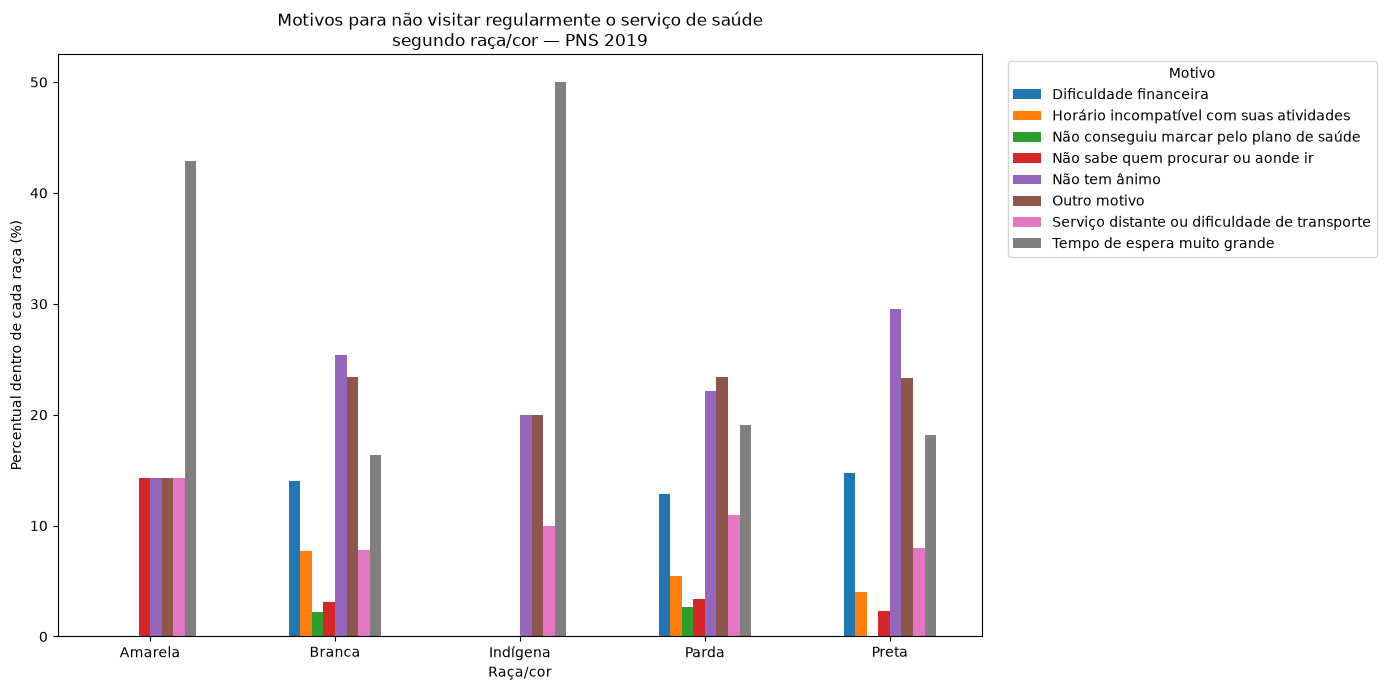

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

descricao_q09502 = {
    2: "Serviço distante ou dificuldade de transporte",
    3: "Não tem ânimo",
    4: "Tempo de espera muito grande",
    5: "Dificuldade financeira",
    6: "Horário incompatível com suas atividades",
    7: "Não conseguiu marcar pelo plano de saúde",
    8: "Não sabe quem procurar ou aonde ir",
    9: "Outro motivo"
}

descricao_raca = {
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena",
    9: "Ignorado"
}

q09502_raca = dados[dados["Ano"] == 2019].copy()

q09502_raca["Q09502"] = pd.to_numeric(
    q09502_raca["Q09502"],
    errors="coerce"
)

q09502_raca["C009"] = pd.to_numeric(
    q09502_raca["C009"],
    errors="coerce"
)

# Remove respostas vazias e o motivo de código 1
q09502_raca = q09502_raca[
    q09502_raca["Q09502"].notna()
    & q09502_raca["C009"].notna()
    & (q09502_raca["Q09502"] != 1)
].copy()

q09502_raca["Motivo"] = (
    q09502_raca["Q09502"]
    .map(descricao_q09502)
)

q09502_raca["Raça/cor"] = (
    q09502_raca["C009"]
    .map(descricao_raca)
)

q09502_raca = q09502_raca.dropna(
    subset=["Motivo", "Raça/cor"]
)

resumo_grafico = (
    q09502_raca
    .groupby(["Raça/cor", "Motivo"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

# Recalcula os percentuais sem considerar o código 1
resumo_grafico["Percentual"] = (
    resumo_grafico["Quantidade"]
    / resumo_grafico.groupby("Raça/cor")["Quantidade"].transform("sum")
    * 100
)

tabela_grafico = resumo_grafico.pivot(
    index="Raça/cor",
    columns="Motivo",
    values="Percentual"
).fillna(0)

tabela_grafico.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Motivos para não visitar regularmente o serviço de saúde\n"
    "segundo raça/cor — PNS 2019"
)

plt.xlabel("Raça/cor")
plt.ylabel("Percentual dentro de cada raça (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Motivo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()